# MAST30034 Project 2 
## Downloading external dataset of pupluation from URL

In [1]:
from urllib.request import urlretrieve
import os

# url for popluation external datasets and save in "landing" dirctory for sebsequent processing
names = ["population_sa2_2001_to_2021"] 
URLS = ["https://www.abs.gov.au/statistics/people/population/regional-population/2021-22/32180DS0003_2001-22r.xlsx"
       ] 
# Create a directory path for storing externally downloaded population data.
output_relpop = '../../data/landing/external_data/'

if not os.path.exists(output_relpop):
    os.makedirs(output_relpop)


# Download the files and save them in the "landing" directory
for i in range(len(names)):
    URLS_TEMPLATE = URLS[i]

    output_dir = output_relpop 
    url = f'{URLS_TEMPLATE}'

    output_dir = f"{output_dir}/{names[i]}.csv"

    urlretrieve(url, output_dir) 
        
    print(f"Completed {names[i]}")


Completed population_sa2_2001_to_2021


## Data pre-processiong of SA2 population in Victoria

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Provide the path to the Excel file (.xlsx)
excel_file_path = '../../data/landing/external_data/population_sa2_2001_to_2021.csv'


# Create an ExcelFile object
execfile = pd.ExcelFile(excel_file_path)
sheetname =execfile.sheet_names

# Print the sheet names
print("Sheet Names:")
for sheet in sheetname:
    print(sheet)


Sheet Names:
Contents
Table 1
Table 2
Table 3
Table 4
Table 5
Explanatory notes


In [4]:
# Load the dataset again to inspect its contents
table1_new = pd.read_excel("../../data/landing/external_data/population_sa2_2001_to_2021.csv", sheet_name="Table 1")


# Extracting the SA2 data for Victoria from "Table 1"
victoria_data = table1_new[table1_new['Unnamed: 1'] == 'Victoria']

# extracted data and ensure their length matches the number of selected columns.
years = victoria_data.iloc[0, 10:31].dropna().values.tolist()

# extract relative populationd data fro the selected year
selected_columns = ['Unnamed: ' + str(i) for i in range(10, 10 + len(years))] 
victoria_population_data = victoria_data[selected_columns]
victoria_population_data.columns = years

# Append the sa2 region
victoria_population_data = victoria_population_data.assign(SA2_NAME=victoria_data['Unnamed: 9'].values)

# Reorder sa2 columns
columns_order = ['SA2_NAME'] + years
victoria_population_data = victoria_population_data[columns_order]
# Rename coloumns to represent the years from 2001 to 2021
victoria_population_data.columns = ['SA2_NAME'] + list(range(2001, 2001 + len(years)))
# Reset the index
victoria_population_data = victoria_population_data.reset_index(drop=True)

# Save updated dataframe to the raw directory
victoria_population_data.to_csv('../../data/raw/external_data/vic_popdata.csv', index=False)
# Display the first few rows of latest dataframe
victoria_population_data

,SA2_NAME,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Alfredton,5756,6092,6293,6480,6648,6761,7034,7272,7614,...,9060,9714,10338,11039,11852,12649,13537,14434,15507,16841
1,Ballarat,11497,11708,12015,12189,12269,12356,12408,12480,12476,...,12357,12352,12327,12300,12301,12266,12244,12320,12196,12071
2,Buninyong,5320,5399,5557,5620,5857,6037,6131,6252,6431,...,6854,6984,7082,7191,7311,7409,7418,7458,7377,7229
3,Delacombe,4154,4225,4371,4465,4704,5041,5206,5349,5557,...,6020,6267,6583,6846,7195,7622,8183,8890,9755,10648
4,Smythes Creek,3317,3378,3411,3473,3508,3542,3594,3658,3714,...,3872,3914,3945,3966,3990,4004,4042,4112,4152,4211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517,Otway,3452,3479,3511,3511,3492,3459,3489,3501,3490,...,3456,3497,3519,3538,3556,3635,3710,3802,3911,3979
518,Moyne - East,6718,6704,6676,6643,6638,6652,6606,6631,6703,...,6764,6749,6734,6716,6709,6717,6746,6798,6883,6990
519,Moyne - West,8317,8387,8450,8487,8517,8601,8694,8792,8878,...,9167,9300,9383,9467,9603,9686,9783,9845,9859,9967
520,Warrnambool - North,17053,17449,17726,17937,18172,18528,18877,19107,19369,...,20253,20612,20930,21217,21442,21688,21954,22184,22416,22470


## Population forecast by altering annual growth rates


In [5]:
# Calcuate the annual growth rate
growth_rates = victoria_population_data.iloc[:, 1:].pct_change(axis=1) * 100

# Append sa2 names
growth_rates['SA2_NAME'] = victoria_population_data['SA2_NAME']

# Move the "SA2_Name" column to be the first column.
columns_order_growth = ['SA2_NAME'] + list(range(2002, 2022))  # 2021 column does not have population growth rate
growth_rates = growth_rates[columns_order_growth]

growth_rates.head()

,SA2_NAME,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Alfredton,5.837387,3.299409,2.971556,2.592593,1.699759,4.037864,3.383566,4.702970,3.677436,...,7.193564,7.218543,6.423718,6.780809,7.364798,6.724603,7.020318,6.626284,7.433837,8.602567
1,Ballarat,1.835261,2.622139,1.448190,0.656329,0.709104,0.420848,0.580271,-0.032051,-0.112215,...,-0.064699,-0.040463,-0.202396,-0.219031,0.008130,-0.284530,-0.179358,0.620712,-1.006494,-1.024926
2,Buninyong,1.484962,2.926468,1.133705,4.217082,3.073246,1.557065,1.973577,2.863084,2.550148,...,1.918216,1.896703,1.403207,1.539113,1.668753,1.340446,0.121474,0.539229,-1.086082,-2.006236
3,Delacombe,1.709196,3.455621,2.150538,5.352744,7.164116,3.273160,2.746831,3.888577,2.555336,...,3.117506,4.102990,5.042285,3.995139,5.097867,5.934677,7.360273,8.639863,9.730034,9.154280
4,Smythes Creek,1.839011,0.976909,1.817649,1.007774,0.969213,1.468097,1.780746,1.530891,1.615509,...,1.387798,1.084711,0.792029,0.532319,0.605144,0.350877,0.949051,1.731816,0.972763,1.421002


In [6]:
# Compute average growth rate over the most recent 5 years
average_growth_rates = growth_rates.iloc[:, -5:].mean(axis=1)
average_growth_rates

0      7.281522
1     -0.374919
2     -0.218234
3      8.163825
4      1.085102
         ...   
517    2.274051
518    0.825347
519    0.747432
520    0.941622
521    0.189561
Length: 522, dtype: float64

In [7]:
# Initialize a dataframe to store the predicted population data
predicted_population = victoria_population_data[['SA2_NAME', 2021]].copy()

# Use the average growth rate to predict the population for the years 2022 to 2026.
for year in range(2022, 2027):
    predicted_population[year] = predicted_population[year - 1] * (1 + average_growth_rates.values / 100)

predicted_population

,SA2_NAME,2021,2022,2023,2024,2025,2026
0,Alfredton,16841,18067.281057,19382.854034,20794.220743,22308.356423,23932.74422
1,Ballarat,12071,12025.743532,11980.656739,11935.738985,11890.989636,11846.408061
2,Buninyong,7229,7213.223879,7197.482187,7181.774849,7166.101789,7150.462933
3,Delacombe,10648,11517.284118,12457.535072,13474.546472,14574.584905,15764.428555
4,Smythes Creek,4211,4256.693634,4302.88309,4349.573749,4396.771049,4444.480488
...,...,...,...,...,...,...,...
517,Otway,3979,4069.484476,4162.026614,4256.673208,4353.472113,4452.472275
518,Moyne - East,6990,7047.691724,7105.859605,7164.507573,7223.639589,7283.25965
519,Moyne - West,9967,10041.496567,10116.549946,10192.164298,10268.343816,10345.092724
520,Warrnambool - North,22470,22681.582416,22895.157137,23110.742925,23328.358716,23548.023624


In [8]:
# Save the processed data to the curated folder
predicted_population.to_csv('../../data/curated/external_data/predicated_pop.csv', index=False)

## Visualization of population data

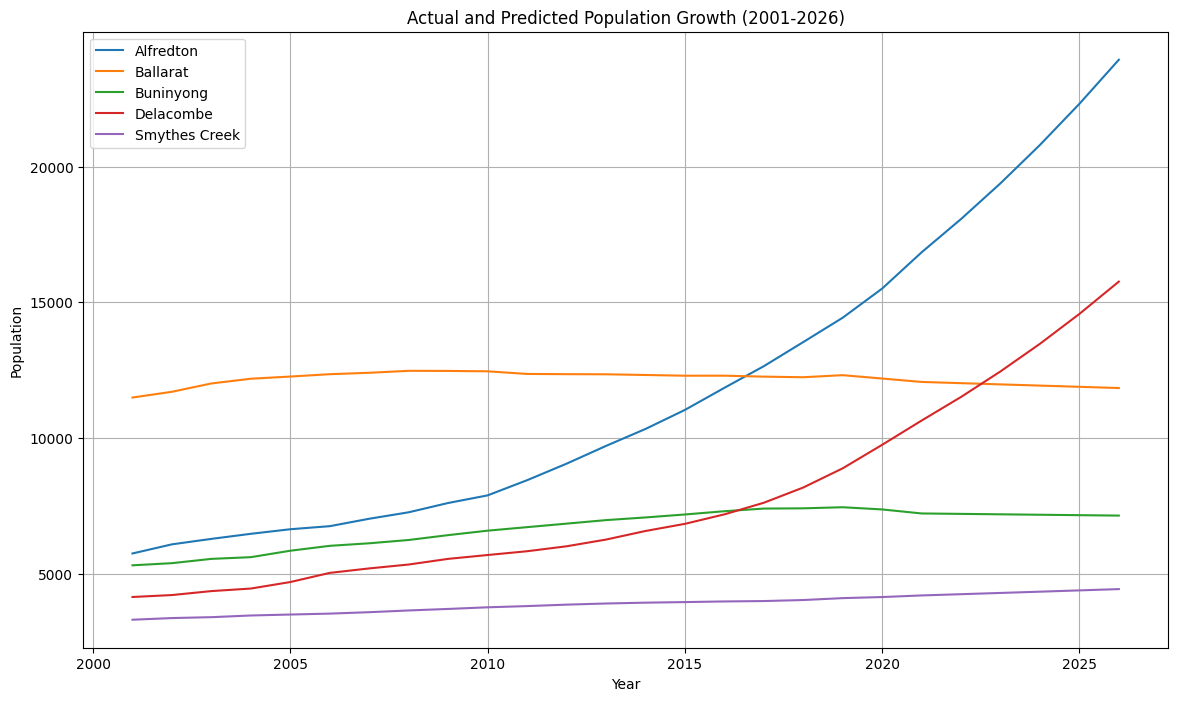

In [9]:
# Plot the actual and predicated population data
import matplotlib.pyplot as plt

# Select a first five sa2 region
sample_sa2_names = predicted_population['SA2_NAME'].head(5)

plt.figure(figsize=(14, 8))

for sa2_name in sample_sa2_names:
    actual_population = victoria_population_data[victoria_population_data['SA2_NAME'] == sa2_name].iloc[:, 1:].squeeze()
    predicted_values = predicted_population[predicted_population['SA2_NAME'] == sa2_name].iloc[:, 1:].squeeze()
    
    # use pandas.concat to concatenate two Series objects. 
    combined_data = pd.concat([actual_population, predicted_values[1:]])
    
    plt.plot(combined_data, label=sa2_name)

plt.title('Actual and Predicted Population Growth (2001-2026)')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_465205/1195257079.py:11: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  gdf = gdf.explode()


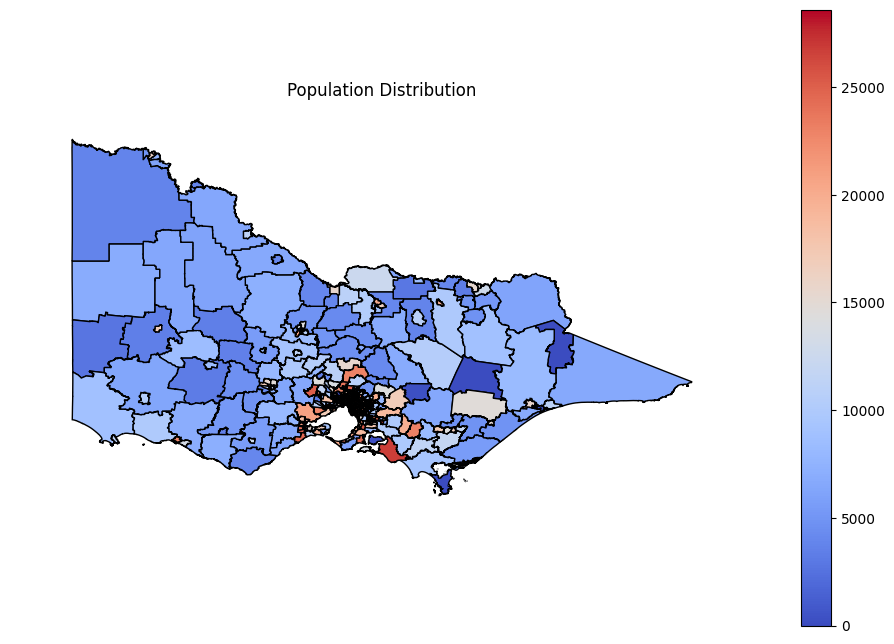

In [10]:
import geopandas as gpd
import geoplot as gplt
import pandas as pd
import matplotlib.pyplot as plt

# Load GeoDataFrame
gdf = gpd.read_file('../../data/landing/external_data/shapefile/SA2_2021_AUST_SHP_GDA2020/SA2_2021_AUST_GDA2020.shp')
gdf = gdf.rename(columns={'SA2_NAME21': 'SA2_NAME'})

# Convert MultiPolygons to Polygons by exploding
gdf = gdf.explode()

# Load the population data from the CSV file as a DataFrame
population_df = pd.read_csv('../../data/curated/external_data/predicated_pop.csv')

# Merge the GeoDataFrame and the DataFrame based on the common column 'SA2_NAME'
merged_df = gdf.merge(population_df, on='SA2_NAME')

# Create a choropleth map
gplt.choropleth(
    merged_df,
    hue='2021',  # Specify the column containing population data
    cmap='coolwarm',           # Choose a colormap
    figsize=(12, 8),           # Set the figure size
    legend=True,               # Show a legend
)

plt.title('Population Distribution')
plt.axis('off')  # Turn off axis labels

plt.show()


In [11]:
predicted_population['avg_growth_rates(%)'] = average_growth_rates
# Display the predicted years
predicted_population

,SA2_NAME,2021,2022,2023,2024,2025,2026,avg_growth_rates(%)
0,Alfredton,16841,18067.281057,19382.854034,20794.220743,22308.356423,23932.74422,7.281522
1,Ballarat,12071,12025.743532,11980.656739,11935.738985,11890.989636,11846.408061,-0.374919
2,Buninyong,7229,7213.223879,7197.482187,7181.774849,7166.101789,7150.462933,-0.218234
3,Delacombe,10648,11517.284118,12457.535072,13474.546472,14574.584905,15764.428555,8.163825
4,Smythes Creek,4211,4256.693634,4302.88309,4349.573749,4396.771049,4444.480488,1.085102
...,...,...,...,...,...,...,...,...
517,Otway,3979,4069.484476,4162.026614,4256.673208,4353.472113,4452.472275,2.274051
518,Moyne - East,6990,7047.691724,7105.859605,7164.507573,7223.639589,7283.25965,0.825347
519,Moyne - West,9967,10041.496567,10116.549946,10192.164298,10268.343816,10345.092724,0.747432
520,Warrnambool - North,22470,22681.582416,22895.157137,23110.742925,23328.358716,23548.023624,0.941622


In [12]:
# Save the processed data to the curated folder
predicted_population.to_csv('../../data/curated/external_data/predicated_pop.csv', index=False)